In [21]:

import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
from hmmlearn.hmm import GaussianHMM

In [65]:
file_path = "vix_data.csv"
vix_data = pd.read_csv(
    file_path,
)

In [13]:
vix_data.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,^VIX,^VIX,^VIX,^VIX,^VIX
1,Date,NaN,NaN,NaN,NaN,NaN
2,2004-01-02,18.219999313354492,18.68000030517578,17.540000915527344,17.959999084472656,0
3,2004-01-05,17.489999771118164,18.489999771118164,17.440000534057617,18.450000762939453,0
4,2004-01-06,16.729999542236328,17.670000076293945,16.190000534057617,17.65999984741211,0


In [14]:
vix_data.dtypes

Price     str
Close     str
High      str
Low       str
Open      str
Volume    str
dtype: object

In [66]:
df = vix_data.copy()
numerical_columns = ["Close", "High", "Low", "Open", "Volume"]
for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.rename(columns={df.columns[0]: "Date"})
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df[["Date", "Close", "High", "Low", "Open", "Volume"]]
df = df.dropna()
df = df[['Date','Close']].dropna()
df = df.sort_values('Date').reset_index(drop=True)
df.head()

/var/folders/b1/bv8q97ln7yl6yb3_mp9pb17h0000gn/T/ipykernel_12120/3644121757.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


,Date,Close
0,2004-01-02,18.219999
1,2004-01-05,17.490000
2,2004-01-06,16.730000
3,2004-01-07,15.500000
4,2004-01-08,15.610000


In [67]:
df["log_vix"] = np.log(df["Close"])
df["return"] = df["log_vix"].diff()                      # rendement log journalier
df["rolling_vol"] = df["return"].rolling(20).std()       # vol réalisée 20j
df["rolling_vol_short"] = df["return"].rolling(5).std()  # vol réalisée 5j
df = df.dropna()
df.head()

,Date,Close,log_vix,return,rolling_vol,rolling_vol_short
20,2004-02-02,17.110001,2.839663,0.028455,0.050911,0.043926
21,2004-02-03,17.340000,2.853016,0.013353,0.050235,0.042758
22,2004-02-04,17.870001,2.883123,0.030107,0.049559,0.024826
23,2004-02-05,17.709999,2.874129,-0.008994,0.046024,0.025854
24,2004-02-06,16.000000,2.772589,-0.101541,0.051994,0.054744


In [68]:
from sklearn.preprocessing import StandardScaler
df_model = df.copy()

# Features basées sur le COMPORTEMENT, pas le niveau absolu
features = ["return", "rolling_vol", "rolling_vol_short"]
X = df_model[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)
model.fit(X_scaled)
df_model["state"] = model.predict(X_scaled)

print(f"Log-vraisemblance : {model.score(X_scaled):.2f}")

Log-vraisemblance : -14300.09


In [69]:
state_order = (
    df_model.groupby("state")["rolling_vol"]
    .mean()
    .sort_values()
    .index
)
mapping = {old: new for new, old in enumerate(state_order)}
df_model["regime"] = df_model["state"].map(mapping)

summary = df_model.groupby("regime")[["Close", "return", "rolling_vol"]].mean()
summary["count"] = df_model.groupby("regime").size()
summary.index = ["Calme", "Intermédiaire", "Crise"]
print(summary.round(4))

print("\nMatrice de transition :")
print(np.round(model.transmat_, 3))

                 Close  return  rolling_vol  count
Calme          16.3809  0.0007       0.0466   2364
Intermédiaire  20.0225 -0.0021       0.0719   1751
Crise          23.6703  0.0018       0.1134   1003

Matrice de transition :
[[0.972 0.02  0.007]
 [0.038 0.941 0.021]
 [0.    0.053 0.947]]


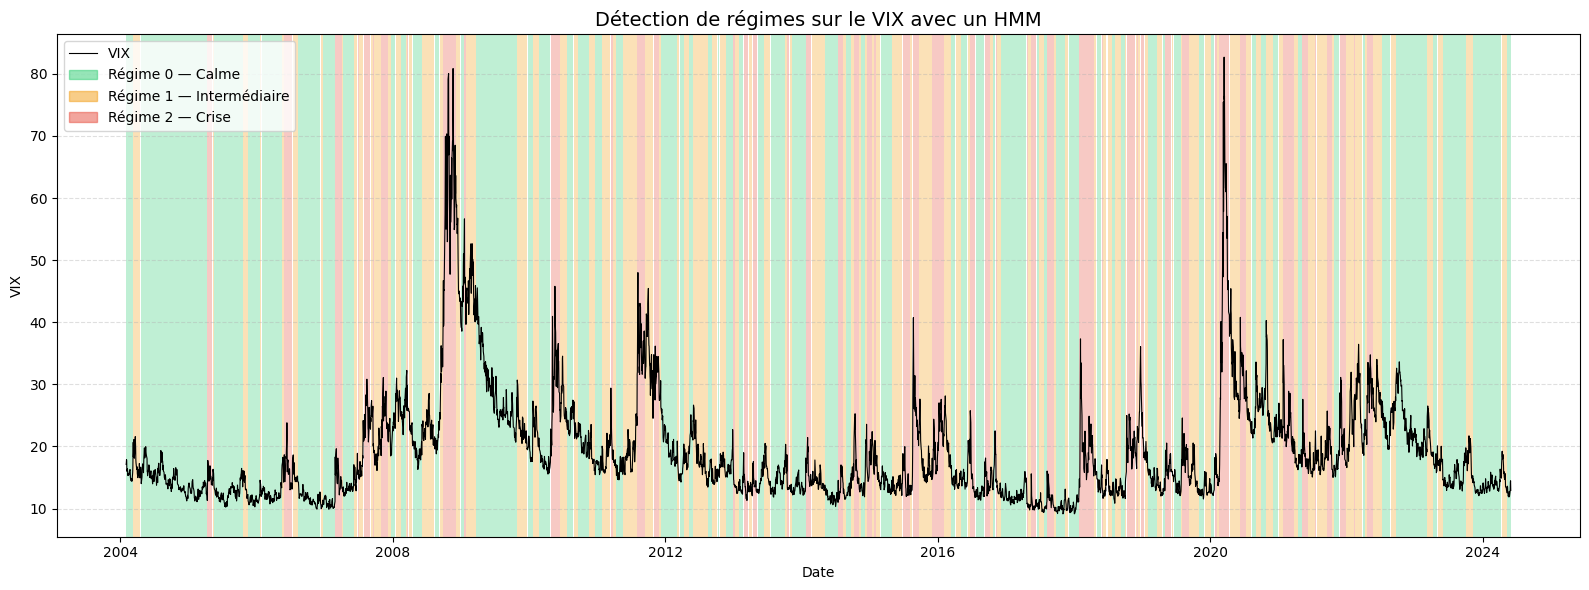

In [70]:
import matplotlib.patches as mpatches
colors = ["#2ecc71", "#f39c12", "#e74c3c"]  # vert, orange, rouge
labels = ["Régime 0 — Calme", "Régime 1 — Intermédiaire", "Régime 2 — Crise"]

fig, ax = plt.subplots(figsize=(16, 6))

# ── Zones colorées de fond pour chaque régime ──────────────────────────────
dates = df_model["Date"].values
regimes = df_model["regime"].values

i = 0
while i < len(regimes):
    r = regimes[i]
    j = i
    while j < len(regimes) and regimes[j] == r:
        j += 1
    ax.axvspan(dates[i], dates[j - 1], alpha=0.3, color=colors[r], linewidth=0)
    i = j

# ── Série VIX par-dessus ────────────────────────────────────────────────────
ax.plot(df_model["Date"], df_model["Close"], color="black", linewidth=0.8, label="VIX")

# ── Légende ────────────────────────────────────────────────────────────────
patches = [mpatches.Patch(color=colors[i], alpha=0.5, label=labels[i]) for i in range(3)]
patches.insert(0, plt.Line2D([0], [0], color="black", linewidth=0.8, label="VIX"))
ax.legend(handles=patches, loc="upper left", fontsize=10)

ax.set_title("Détection de régimes sur le VIX avec un HMM", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("VIX")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()